# SQL Results - Orders

## 1.0 Import necessary libraries

In [1]:
# Data analysis
import pandas as pd

# Directory
from pathlib import Path

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## 2.0 Paths setup

In [3]:
# Current directory
CURRENT_DIR = Path.cwd()

# Path to main folder
PROJECT_ROOT = CURRENT_DIR.parent.parent

# Path to folders
RESULTS_FOLDER = PROJECT_ROOT/"SQL_results"
ORDER_ANALYSIS_RESULTS = RESULTS_FOLDER/"order_analysis"

## 3.0 Order Analysis

### 3.1 Total orders

In [4]:
total_orders = pd.read_csv(ORDER_ANALYSIS_RESULTS/"total_orders.csv")
total_orders

,TotalOrders
0,19959


### 3.2 Top 5 months by total orders

In [5]:
top_5_months = pd.read_csv(ORDER_ANALYSIS_RESULTS/"top_5_months_orders.csv")
top_5_months

,OrderMonth,TotalOrders
0,2011-11,2769
1,2011-10,2040
2,2011-09,1837
3,2011-05,1681
4,2010-12,1559


### 3.3 Bottom 5 months by total orders

In [6]:
bottom_5_months = pd.read_csv(ORDER_ANALYSIS_RESULTS/"bottom_5_months_orders.csv")
bottom_5_months

,OrderMonth,TotalOrders
0,2011-12,819
1,2011-01,1086
2,2011-02,1100
3,2011-04,1246
4,2011-08,1360


### 3.4 Orders per month

In [7]:
orders_per_month = pd.read_csv(ORDER_ANALYSIS_RESULTS/"orders_per_month.csv")

# Change Months to actual names
orders_per_month['OrderMonth'] = pd.to_datetime(orders_per_month['OrderMonth']).dt.strftime('%b %Y')

orders_per_month

,OrderMonth,TotalOrders
0,Dec 2011,819
1,Nov 2011,2769
2,Oct 2011,2040
3,Sep 2011,1837
4,Aug 2011,1360
5,Jul 2011,1475
6,Jun 2011,1533
7,May 2011,1681
8,Apr 2011,1246
9,Mar 2011,1454


### 3.5 Orders per country

In [8]:
orders_per_country = pd.read_csv(ORDER_ANALYSIS_RESULTS/"orders_per_country.csv")
orders_per_country

,Country,TotalOrders
0,United Kingdom,18018
1,Germany,457
2,France,392
3,EIRE,288
4,Belgium,98
5,Netherlands,94
6,Spain,90
7,Portugal,58
8,Australia,57
9,Switzerland,54


In [9]:
# Column for percentage of customers from the UK
UK_orders = (orders_per_country[orders_per_country['Country']=='United Kingdom']['TotalOrders'] / total_orders['TotalOrders']) * 100

print(f'Percentage of orders from United Kingdom: {UK_orders}')

Percentage of orders from United Kingdom: 0    90.275064
Name: TotalOrders, dtype: float64


### 3.6 Total items per order

In [10]:
total_items_per_order = pd.read_csv(ORDER_ANALYSIS_RESULTS/"total_items_per_order.csv")
total_items_per_order

,InvoiceNo,TotalDistinctProducts,TotalQuantity,TotalSales
0,581483,1,80995,168469.60
1,541431,1,74215,77183.60
2,556917,138,15049,22775.93
3,563076,119,14730,19150.66
4,574941,101,14149,52940.94
...,...,...,...,...
19954,551419,1,1,400.00
19955,560431,1,1,611.86
19956,560187,1,1,550.94
19957,564196,1,1,15.00


## 4.0 Visualisation

### 4.1 Orders per month

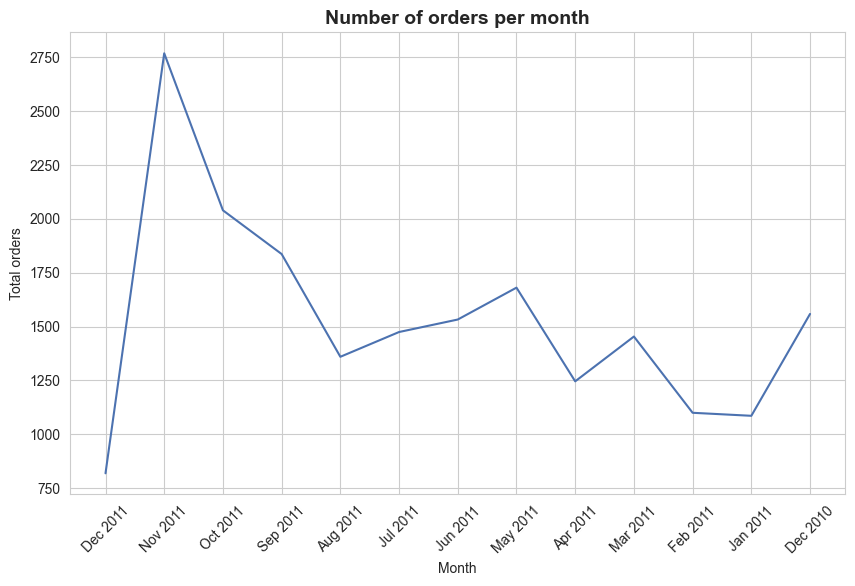

In [11]:
# Set style
sns.set_style("whitegrid")

# Colour
sns.set_palette("deep")

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=orders_per_month, x='OrderMonth', y='TotalOrders')
plt.title('Number of orders per month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total orders')
plt.xticks(rotation=45)
plt.show()